# Final Report Reproducible Visualizations

This notebook regenerates the final-report visualizations from data and derived outputs stored in this repository.

It is intended to make the report figures auditable: every plot is produced from project files under `data/` or `outputs/`, then saved to `outputs/visualizations/reproducible_report_figures/`.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import geopandas as gpd
except ImportError:
    gpd = None

sns.set_theme(style="whitegrid", context="notebook")

cwd = Path.cwd().resolve()
ROOT = next(
    (p for p in [cwd, *cwd.parents] if (p / "data").exists() and (p / "outputs").exists()),
    cwd,
)
FIG_DIR = ROOT / "outputs" / "visualizations" / "reproducible_report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUBRIC = ROOT / "outputs" / "modeling" / "rubric_completion"
PRIMARY = ROOT / "outputs" / "modeling" / "primary_notebook"

print(f"Repository root: {ROOT}")
print(f"Figure output directory: {FIG_DIR}")

Repository root: /Users/sophiaboettcher/Milestone-II-Project/SIADS696-Team7-Clean-Repo/final_clean_repo
Figure output directory: /Users/sophiaboettcher/Milestone-II-Project/SIADS696-Team7-Clean-Repo/final_clean_repo/outputs/visualizations/reproducible_report_figures


## Load Project Data

In [2]:
metrics = pd.read_csv(RUBRIC / "supervised_cv_metrics_with_sd.csv")
predictions = pd.read_csv(RUBRIC / "best_rf_holdout_predictions.csv", dtype={"geoid": str})
importance = pd.read_csv(RUBRIC / "rf_feature_importance.csv")
ablation = pd.read_csv(RUBRIC / "rf_feature_family_ablation.csv")
sensitivity = pd.read_csv(RUBRIC / "rf_sensitivity_grid.csv")
unsup_search = pd.read_csv(RUBRIC / "unsupervised_method_search.csv")
unsup_assign = pd.read_csv(RUBRIC / "unsupervised_two_method_assignments.csv", dtype={"geoid": str})
db_profile = pd.read_csv(RUBRIC / "dbscan_cluster_profile.csv")
km_profile = pd.read_csv(RUBRIC / "kmeans_cluster_profile.csv")

county_panel = pd.read_csv(ROOT / "data" / "processed" / "county_panel_enriched.csv", dtype={"geoid": str})

predictions["geoid"] = predictions["geoid"].str.zfill(5)
unsup_assign["geoid"] = unsup_assign["geoid"].str.zfill(5)

display(metrics)
display(unsup_search.tail())

,model,holdout_rmse,holdout_mae,holdout_r2,cv_rmse_mean,cv_rmse_sd,cv_mae_mean,cv_mae_sd,cv_r2_mean,cv_r2_sd,best_params
0,Random Forest tuned,1.979807,1.651304,-0.017985,2.017443,0.633331,1.747498,0.603042,0.009644,0.503789,"{'model__max_features': 'sqrt', 'model__min_sa..."
1,Gradient Boosting tuned,2.299988,1.914584,-0.373872,2.164349,0.487778,1.848643,0.460234,-0.094853,0.439860,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,ElasticNet tuned,2.307526,1.974127,-0.382893,2.315859,0.587243,1.962854,0.539314,-0.266816,0.552015,"{'model__alpha': 0.1, 'model__l1_ratio': 0.9}"
3,Dummy mean baseline,2.432019,1.954795,-0.536135,2.729924,0.455684,2.229633,0.395112,-0.696172,0.496348,{}


,method,params,clusters,noise_pct,silhouette_embedding,silhouette_scaled_features,calinski_harabasz
70,KMeans,k=2,2,0.0,0.889502,0.747254,321.487348
71,KMeans,k=3,3,0.0,0.703746,0.353791,286.164922
72,KMeans,k=4,4,0.0,0.140802,0.084741,265.688502
73,KMeans,k=5,5,0.0,0.135700,0.083545,255.309245
74,KMeans,k=6,6,0.0,0.208392,0.084281,247.653419


## Helper Functions

In [3]:
def savefig(name, width=8, height=5):
    path = FIG_DIR / name
    plt.gcf().set_size_inches(width, height)
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"saved {path.relative_to(ROOT)}")
    return path

def clean_label(value):
    return str(value).replace("_", " ").title()

## Supervised Figure 1: Three-Panel Model Accuracy (Predicted vs. Actual)

This figure requires `all_model_holdout_predictions.csv`, generated by `generate_three_panel.py`.
Run that script first if the file does not exist.

In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse_score, mean_absolute_error, r2_score

all_preds_path = RUBRIC / "all_model_holdout_predictions.csv"
if all_preds_path.exists():
    all_preds = pd.read_csv(all_preds_path, dtype={"geoid": str})
    y_actual = all_preds["next_year_fmd"].values

    models = [
        ("Tuned ElasticNet", all_preds["pred_elasticnet"].values),
        ("Tuned Random Forest", all_preds["pred_random_forest"].values),
        ("Tuned XGBoost", all_preds["pred_gradient_boosting"].values),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    labels = ["(a)", "(b)", "(c)"]

    for ax, (name, pred), lbl in zip(axes, models, labels):
        ax.scatter(y_actual, pred, alpha=0.35, s=14, edgecolors="none", color="#4C72B0")
        lims = [min(y_actual.min(), pred.min()) - 0.5, max(y_actual.max(), pred.max()) + 0.5]
        ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
        r2 = r2_score(y_actual, pred)
        ax.text(0.05, 0.95,
                f"RMSE = {rmse_score(y_actual, pred):.2f}\nMAE  = {mean_absolute_error(y_actual, pred):.2f}\nR²   = {r2:.3f}",
                transform=ax.transAxes, va="top", fontsize=10, family="monospace",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.9))
        ax.set_title(f"{lbl} {name}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Actual Next-Year FMD (%)", fontsize=11)
        if ax == axes[0]:
            ax.set_ylabel("Predicted Next-Year FMD (%)", fontsize=11)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.grid(True, alpha=0.2)

    plt.suptitle("Hyperparameter-Tuned Model Accuracy", fontsize=15, fontweight="bold", y=1.02)
    savefig("figure_01_three_panel_model_accuracy.png", 18, 5)
    plt.show()
else:
    print(f"⚠️  {all_preds_path} not found. Run generate_three_panel.py first.")

## Supervised Figure 1b: Model Comparison Bar Chart (Cross-Validation)

saved outputs/visualizations/reproducible_report_figures/figure_01_supervised_model_comparison.png


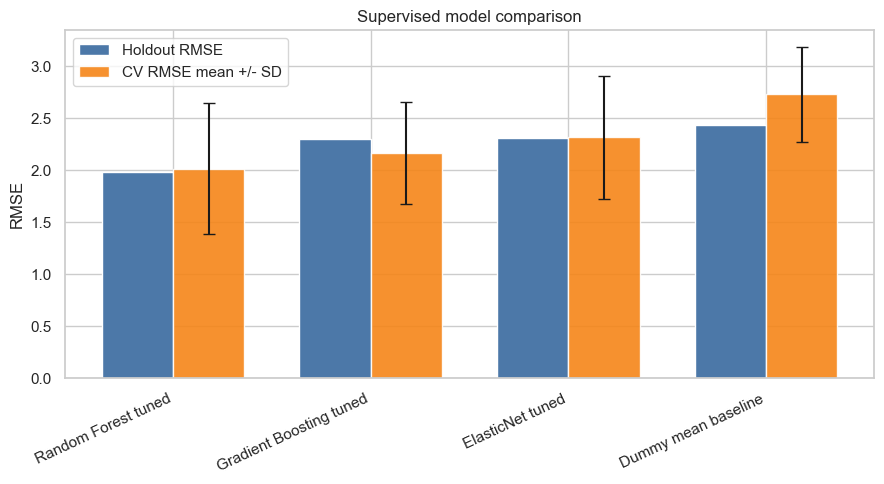

In [4]:
plot_df = metrics.sort_values("holdout_rmse").copy()
order = plot_df["model"].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
ax.bar(x - 0.18, plot_df["holdout_rmse"], width=0.36, label="Holdout RMSE", color="#4C78A8")
ax.bar(x + 0.18, plot_df["cv_rmse_mean"], width=0.36, yerr=plot_df["cv_rmse_sd"], capsize=4,
       label="CV RMSE mean +/- SD", color="#F58518", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Supervised model comparison")
ax.legend()
savefig("figure_01_supervised_model_comparison.png", 9, 5)
plt.show()

## Supervised Figure 2: Prediction Error Pattern

saved outputs/visualizations/reproducible_report_figures/figure_02_predictions_residuals.png


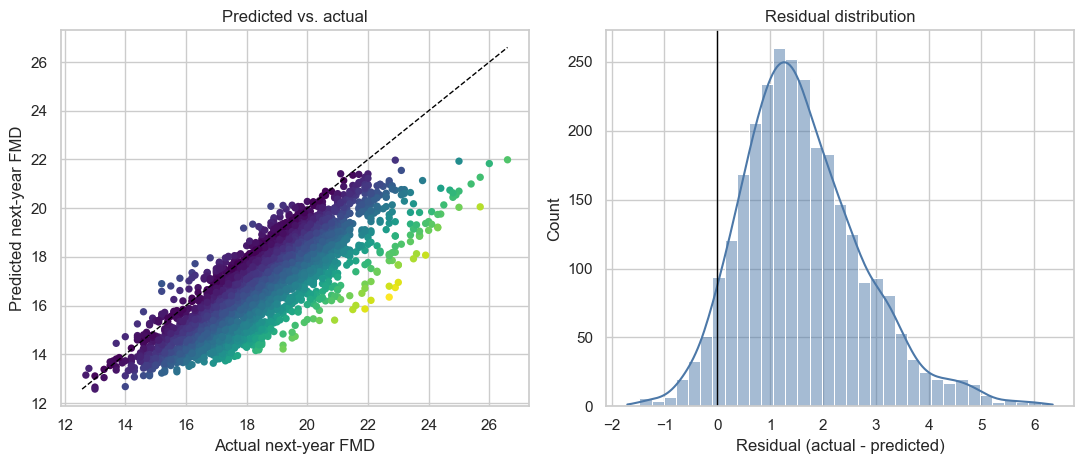

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

sns.scatterplot(
    data=predictions,
    x="next_year_fmd",
    y="prediction",
    hue="abs_residual",
    palette="viridis",
    s=28,
    linewidth=0,
    ax=axes[0],
    legend=False,
)
lo = min(predictions["next_year_fmd"].min(), predictions["prediction"].min())
hi = max(predictions["next_year_fmd"].max(), predictions["prediction"].max())
axes[0].plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Actual next-year FMD")
axes[0].set_ylabel("Predicted next-year FMD")
axes[0].set_title("Predicted vs. actual")

sns.histplot(predictions["residual"], bins=35, kde=True, color="#4C78A8", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Residual (actual - predicted)")
axes[1].set_title("Residual distribution")

savefig("figure_02_predictions_residuals.png", 11, 4.8)
plt.show()

## Supervised Figure 3: Geographic Residual Map

saved outputs/visualizations/reproducible_report_figures/figure_03_residual_map.png


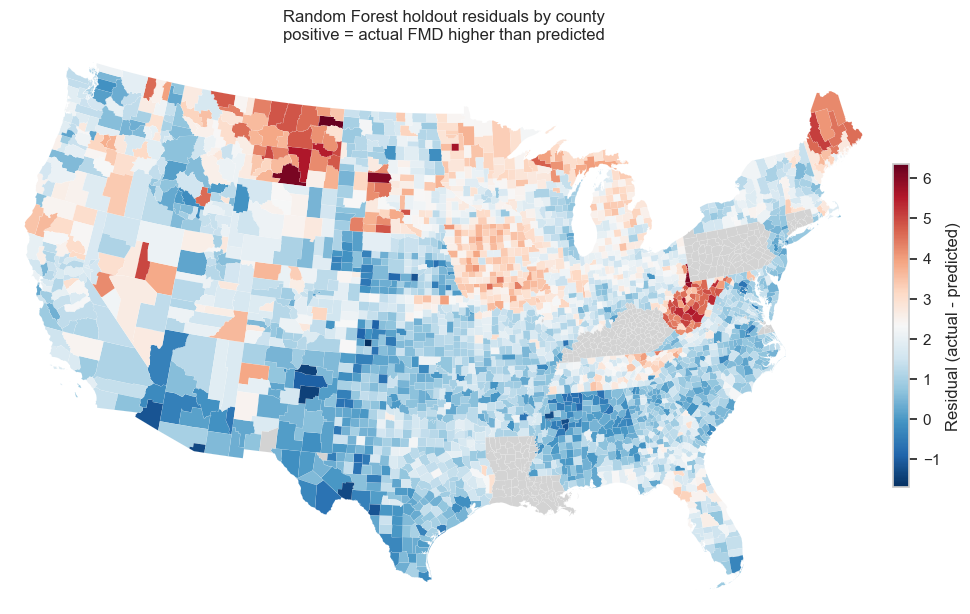

In [6]:
if gpd is None:
    print("geopandas is not installed; skipping residual map.")
else:
    census_zip = ROOT / "data" / "raw" / "census_geography" / "cb_2023_us_county_500k.zip"
    if not census_zip.exists():
        census_zip = ROOT / "data" / "raw" / "census" / "cb_2023_us_county_500k.zip"
    if not census_zip.exists():
        raise FileNotFoundError(f"Missing Census county boundary zip: {census_zip}")

    counties = gpd.read_file(f"zip://{census_zip}")
    counties["GEOID"] = counties["GEOID"].astype(str).str.zfill(5)
    lower_48_plus_dc = {
        "AL", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL", "GA",
        "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", "MA",
        "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ", "NM",
        "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD",
        "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY",
    }
    counties = counties[counties["STUSPS"].isin(lower_48_plus_dc)].copy()
    mapped = counties.merge(predictions, left_on="GEOID", right_on="geoid", how="left")
    mapped = mapped.to_crs("EPSG:5070")

    fig, ax = plt.subplots(figsize=(11, 6.2))
    mapped.plot(
        column="residual",
        cmap="RdBu_r",
        legend=True,
        legend_kwds={"label": "Residual (actual - predicted)", "shrink": 0.58, "pad": 0.015},
        missing_kwds={"color": "lightgrey", "label": "No prediction"},
        ax=ax,
        linewidth=0.05,
        edgecolor="white",
    )
    minx, miny, maxx, maxy = mapped.total_bounds
    ax.set_xlim(minx - 80_000, maxx + 80_000)
    ax.set_ylim(miny - 80_000, maxy + 80_000)
    ax.set_axis_off()
    ax.set_title("Random Forest holdout residuals by county\npositive = actual FMD higher than predicted")
    savefig("figure_03_residual_map.png", 11, 6.2)
    plt.show()

## Supervised Figure 4: Random Forest Feature Importance

saved outputs/visualizations/reproducible_report_figures/figure_04_rf_feature_importance.png


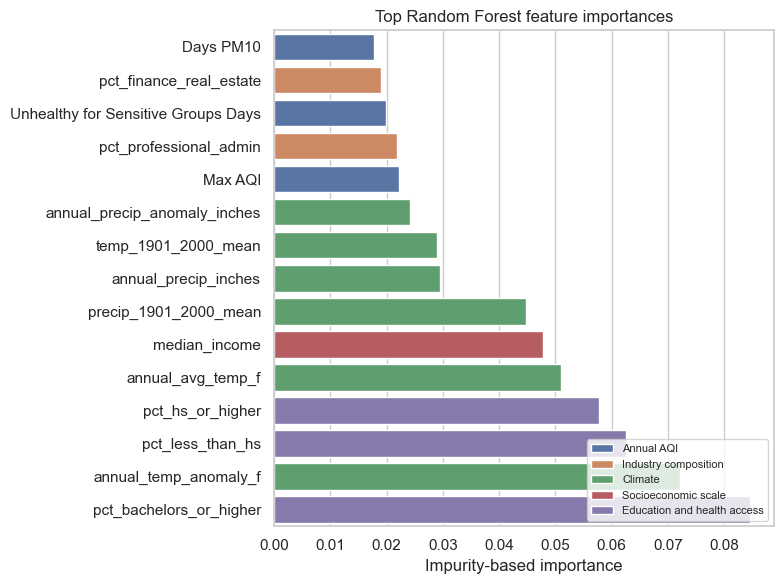

In [7]:
top = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top, x="importance", y="feature", hue="family", dodge=False, ax=ax)
ax.set_xlabel("Impurity-based importance")
ax.set_ylabel("")
ax.set_title("Top Random Forest feature importances")
ax.legend(loc="lower right", fontsize=8)
savefig("figure_04_rf_feature_importance.png", 8, 6)
plt.show()

## Supervised Figure 5: Feature-Family Ablation

saved outputs/visualizations/reproducible_report_figures/figure_05_rf_ablation.png


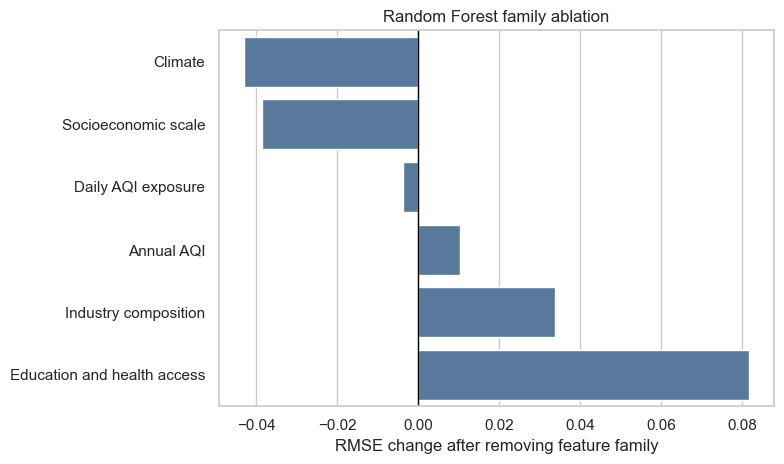

In [8]:
plot_df = ablation[ablation["removed_family"] != "None (full model)"].sort_values("rmse_delta")
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=plot_df, x="rmse_delta", y="removed_family", color="#4C78A8", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("RMSE change after removing feature family")
ax.set_ylabel("")
ax.set_title("Random Forest family ablation")
savefig("figure_05_rf_ablation.png", 8, 4.8)
plt.show()

## Supervised Figure 6: Random Forest Sensitivity

saved outputs/visualizations/reproducible_report_figures/figure_06_rf_sensitivity.png


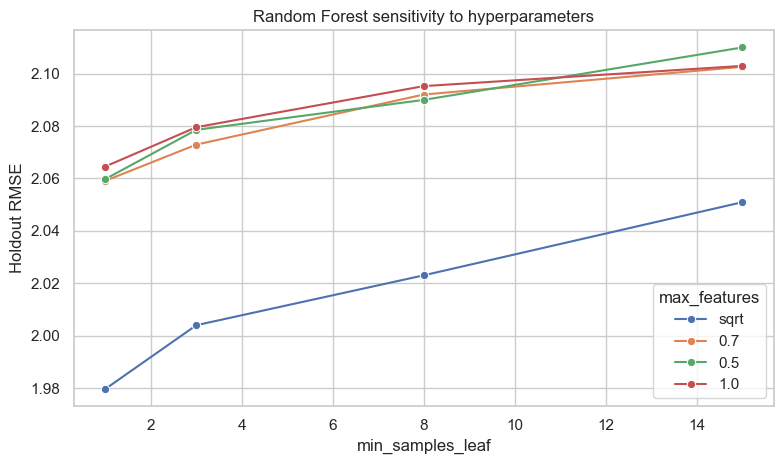

In [9]:
sens = sensitivity.copy()
sens["max_features"] = sens["max_features"].astype(str)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.lineplot(data=sens, x="min_samples_leaf", y="holdout_rmse", hue="max_features", marker="o", ax=ax)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("Holdout RMSE")
ax.set_title("Random Forest sensitivity to hyperparameters")
savefig("figure_06_rf_sensitivity.png", 8, 4.8)
plt.show()

## Unsupervised Figure 1: DBSCAN PCA Scatter

saved outputs/visualizations/reproducible_report_figures/figure_07_dbscan_pca_scatter.png


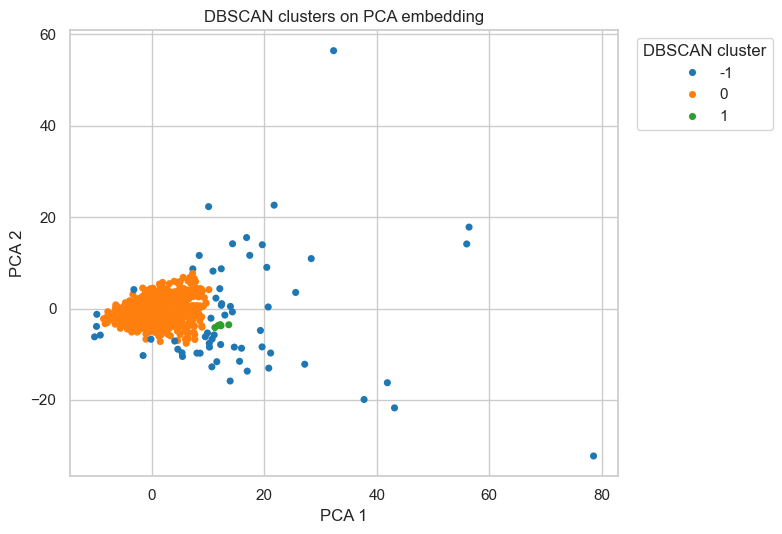

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = sns.scatterplot(
    data=unsup_assign,
    x="pca_1",
    y="pca_2",
    hue="dbscan_cluster",
    palette="tab10",
    s=26,
    linewidth=0,
    ax=ax,
)
ax.set_title("DBSCAN clusters on PCA embedding")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="DBSCAN cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("figure_07_dbscan_pca_scatter.png", 8, 5.5)
plt.show()

## Unsupervised Figure 2: DBSCAN Cluster Profiles

saved outputs/visualizations/reproducible_report_figures/figure_08_dbscan_cluster_profile.png


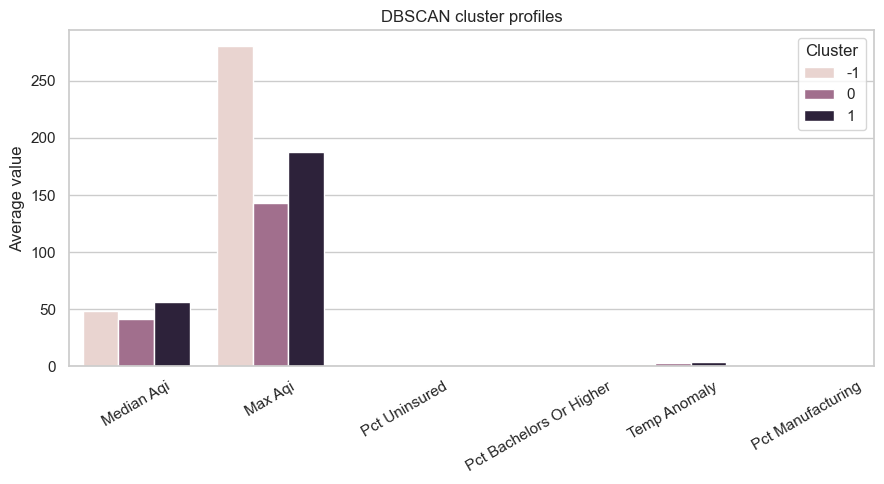

In [11]:
profile_cols = [c for c in db_profile.columns if c.startswith("avg_") and c != "avg_fmd"]
db_long = db_profile.melt(id_vars=["dbscan_cluster"], value_vars=profile_cols, var_name="feature", value_name="value")
db_long["feature"] = db_long["feature"].str.replace("avg_", "", regex=False).map(clean_label)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=db_long, x="feature", y="value", hue="dbscan_cluster", ax=ax)
ax.set_title("DBSCAN cluster profiles")
ax.set_xlabel("")
ax.set_ylabel("Average value")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Cluster")
savefig("figure_08_dbscan_cluster_profile.png", 9, 5)
plt.show()

## Unsupervised Figure 3: K-Means PCA Scatter

saved outputs/visualizations/reproducible_report_figures/figure_09_kmeans_pca_scatter.png


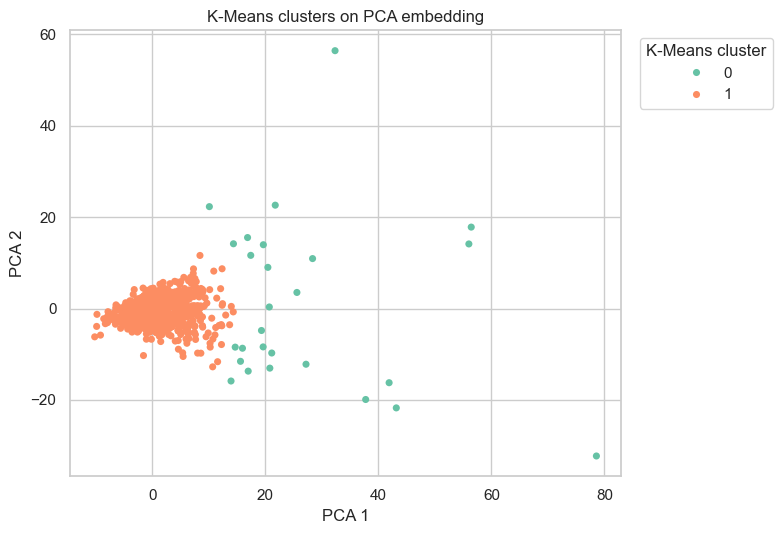

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(
    data=unsup_assign,
    x="pca_1",
    y="pca_2",
    hue="kmeans_cluster",
    palette="Set2",
    s=26,
    linewidth=0,
    ax=ax,
)
ax.set_title("K-Means clusters on PCA embedding")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="K-Means cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("figure_09_kmeans_pca_scatter.png", 8, 5.5)
plt.show()

## Unsupervised Figure 4: K-Means Cluster Profiles

saved outputs/visualizations/reproducible_report_figures/figure_10_kmeans_cluster_profile.png


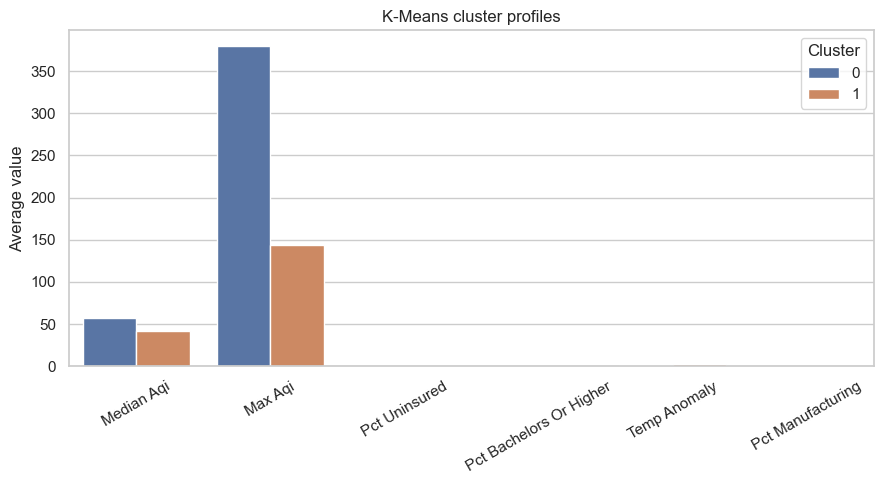

In [13]:
profile_cols = [c for c in km_profile.columns if c.startswith("avg_") and c != "avg_fmd"]
km_long = km_profile.melt(id_vars=["kmeans_cluster"], value_vars=profile_cols, var_name="feature", value_name="value")
km_long["feature"] = km_long["feature"].str.replace("avg_", "", regex=False).map(clean_label)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=km_long, x="feature", y="value", hue="kmeans_cluster", ax=ax)
ax.set_title("K-Means cluster profiles")
ax.set_xlabel("")
ax.set_ylabel("Average value")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Cluster")
savefig("figure_10_kmeans_cluster_profile.png", 9, 5)
plt.show()

## Unsupervised Sensitivity Figure: Parameter Search

DBSCAN settings: 70; K-Means settings: 5; total search rows: 75


saved outputs/visualizations/reproducible_report_figures/figure_11_unsupervised_parameter_search.png


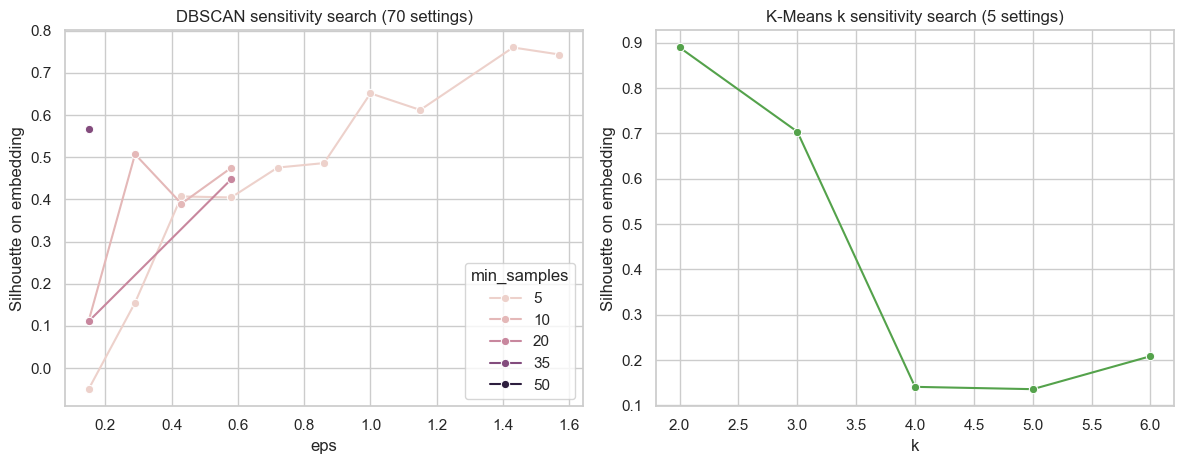

In [14]:
search = unsup_search.copy()
dbscan = search[search["method"].eq("DBSCAN")].copy()
dbscan["eps"] = dbscan["params"].str.extract(r"eps=([0-9.]+)").astype(float)
dbscan["min_samples"] = dbscan["params"].str.extract(r"min_samples=([0-9]+)").astype(int)

kmeans = search[search["method"].eq("KMeans")].copy()
kmeans["k"] = kmeans["params"].str.extract(r"k=([0-9]+)").astype(int)

dbscan_n = len(dbscan)
kmeans_n = len(kmeans)
print(f"DBSCAN settings: {dbscan_n}; K-Means settings: {kmeans_n}; total search rows: {dbscan_n + kmeans_n}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.lineplot(data=dbscan, x="eps", y="silhouette_embedding", hue="min_samples", marker="o", ax=axes[0])
axes[0].set_title(f"DBSCAN sensitivity search ({dbscan_n} settings)")
axes[0].set_ylabel("Silhouette on embedding")
axes[0].set_xlabel("eps")

sns.lineplot(data=kmeans, x="k", y="silhouette_embedding", marker="o", color="#54A24B", ax=axes[1])
axes[1].set_title(f"K-Means k sensitivity search ({kmeans_n} settings)")
axes[1].set_ylabel("Silhouette on embedding")
axes[1].set_xlabel("k")

savefig("figure_11_unsupervised_parameter_search.png", 12, 4.8)
plt.show()

## Generated Figure Manifest

In [15]:
generated_figures = [
    "figure_01_supervised_model_comparison.png",
    "figure_02_predictions_residuals.png",
    "figure_03_residual_map.png",
    "figure_04_rf_feature_importance.png",
    "figure_05_rf_ablation.png",
    "figure_06_rf_sensitivity.png",
    "figure_07_dbscan_pca_scatter.png",
    "figure_08_dbscan_cluster_profile.png",
    "figure_09_kmeans_pca_scatter.png",
    "figure_10_kmeans_cluster_profile.png",
    "figure_11_unsupervised_parameter_search.png",
]

missing = [name for name in generated_figures if not (FIG_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing generated figure files: {missing}")

manifest = pd.DataFrame(
    {
        "figure_file": generated_figures,
        "source": "Generated by notebooks/06_visualization_generation/Final_Report_Reproducible_Visualizations.ipynb from project data/outputs",
    }
)
manifest.to_csv(FIG_DIR / "figure_manifest.csv", index=False)
display(manifest)

,figure_file,source
0,figure_01_supervised_model_comparison.png,Generated by notebooks/06_visualization_genera...
1,figure_02_predictions_residuals.png,Generated by notebooks/06_visualization_genera...
2,figure_03_residual_map.png,Generated by notebooks/06_visualization_genera...
3,figure_04_rf_feature_importance.png,Generated by notebooks/06_visualization_genera...
4,figure_05_rf_ablation.png,Generated by notebooks/06_visualization_genera...
5,figure_06_rf_sensitivity.png,Generated by notebooks/06_visualization_genera...
6,figure_07_dbscan_pca_scatter.png,Generated by notebooks/06_visualization_genera...
7,figure_08_dbscan_cluster_profile.png,Generated by notebooks/06_visualization_genera...
8,figure_09_kmeans_pca_scatter.png,Generated by notebooks/06_visualization_genera...
9,figure_10_kmeans_cluster_profile.png,Generated by notebooks/06_visualization_genera...
